In [1]:
import pandas as pd
import numpy as np
import joblib

from sklearn.svm import OneClassSVM
from sklearn.neighbors import LocalOutlierFactor
from sklearn.ensemble import IsolationForest

import matplotlib.pyplot as plt

In [3]:
import pandas as pd

df = pd.read_csv("../DATA/Processed_data/df_final.csv")

df.rename(columns={'Unnamed: 0': 'date'}, inplace=True)

df['date'] = pd.to_datetime(df['date'])

df.set_index('date', inplace=True)

df.head()

,amount,transaction_type,deposit_amount,withdrawal_amount,net_flow,hour,day_of_week,is_weekend,hour_sin,hour_cos,lag_1,lag_24,rolling_mean_24,rolling_std_24,net_flow_diff,pct_change,year,inflation_rate,interest_rate
date,,,,,,,,,,,,,,,,,,,
1970-01-01 00:00:00.000000000,10526.06,transferdepositpaymentdepositdepositdeposittra...,8620.73,1905.33,6715.40,0,6,1,0.000000,1.000000,6715.40,6715.4,43639.46125,26245.29765,-1386.92,-0.206528,2023,5.649143,6.247603
1970-01-01 00:00:00.000000001,17179.44,transferdepositpaymentpaymentpaymentdepositpay...,11253.96,5925.48,5328.48,1,6,1,0.258819,0.965926,6715.40,6715.4,43639.46125,26245.29765,-1386.92,-0.206528,2023,5.649143,6.448013
1970-01-01 00:00:00.000000002,26571.44,paymenttransfertransferwithdrawaldeposittransf...,19905.36,6666.08,13239.28,2,6,1,0.500000,0.866025,5328.48,6715.4,43639.46125,26245.29765,7910.80,1.484626,2023,5.649143,6.399645
1970-01-01 00:00:00.000000003,43071.17,transferwithdrawalwithdrawalwithdrawaldepositd...,33653.62,9417.55,24236.07,3,6,1,0.707107,0.707107,13239.28,6715.4,43639.46125,26245.29765,10996.79,0.830618,2023,5.649143,6.709553
1970-01-01 00:00:00.000000004,44987.32,deposittransferpaymentpaymentdeposittransferde...,32357.57,12629.75,19727.82,4,6,1,0.866025,0.500000,24236.07,6715.4,43639.46125,26245.29765,-4508.25,-0.186014,2023,5.649143,6.286047


In [17]:
scaler.feature_names_in_

array(['net_flow', 'lag_1', 'lag_24', 'rolling_mean_24', 'rolling_std_24',
       'pct_change', 'net_flow_diff', 'hour_sin', 'hour_cos',
       'is_weekend', 'interest_rate'], dtype=object)

In [18]:
features = list(scaler.feature_names_in_)

In [19]:
X = df[features].dropna()

In [20]:
X_scaled = scaler.transform(X)

In [22]:
import joblib
import numpy as np

iso_model = joblib.load("../models/isolation_forest.pkl")

iso_preds = iso_model.predict(X_scaled)


iso_preds = np.where(iso_preds == -1, 1, 0)

c:\Users\phuta\Downloads\ML_Project\ml_project_env\Lib\site-packages\sklearn\base.py:463: InconsistentVersionWarning: Trying to unpickle estimator ExtraTreeRegressor from version 1.7.2 when using version 1.8.0. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
c:\Users\phuta\Downloads\ML_Project\ml_project_env\Lib\site-packages\sklearn\base.py:463: InconsistentVersionWarning: Trying to unpickle estimator IsolationForest from version 1.7.2 when using version 1.8.0. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(


In [23]:
svm_model = OneClassSVM(nu=0.01, kernel='rbf', gamma='scale')
svm_preds = svm_model.fit_predict(X_scaled)
svm_preds = np.where(svm_preds == -1, 1, 0)

In [24]:
lof_model = LocalOutlierFactor(n_neighbors=20, contamination=0.01)
lof_preds = lof_model.fit_predict(X_scaled)
lof_preds = np.where(lof_preds == -1, 1, 0)

In [25]:
comparison = pd.DataFrame({
    'IsolationForest': iso_preds,
    'OneClassSVM': svm_preds,
    'LOF': lof_preds
}, index=X.index)

comparison.head()

,IsolationForest,OneClassSVM,LOF
date,,,
1970-01-01 00:00:00.000000000,1,1,0
1970-01-01 00:00:00.000000001,1,0,0
1970-01-01 00:00:00.000000002,1,1,0
1970-01-01 00:00:00.000000003,1,1,0
1970-01-01 00:00:00.000000004,1,0,0


In [26]:
comparison.sum()

IsolationForest     87
OneClassSVM        112
LOF                 88
dtype: int64

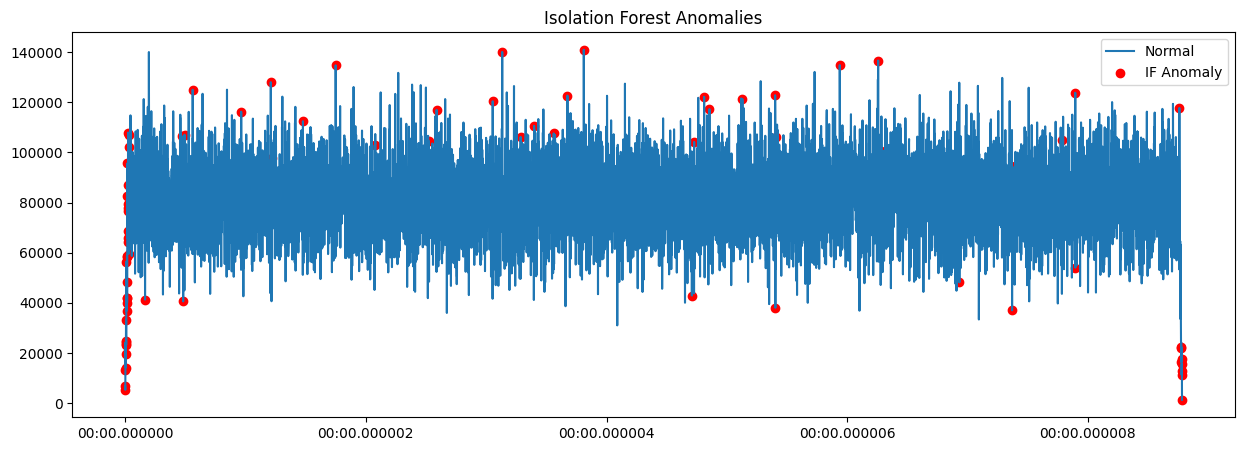

In [27]:
plt.figure(figsize=(15,5))

plt.plot(df.loc[X.index].index, df.loc[X.index]['net_flow'], label='Normal')

anomalies = comparison[comparison['IsolationForest'] == 1]

plt.scatter(anomalies.index,
            df.loc[anomalies.index]['net_flow'],
            color='red',
            label='IF Anomaly')

plt.legend()
plt.title("Isolation Forest Anomalies")
plt.show()

In [28]:
comparison['IF_SVM'] = (comparison['IsolationForest'] == 1) & (comparison['OneClassSVM'] == 1)

comparison['IF_LOF'] = (comparison['IsolationForest'] == 1) & (comparison['LOF'] == 1)

comparison['ALL_THREE'] = (
    (comparison['IsolationForest'] == 1) &
    (comparison['OneClassSVM'] == 1) &
    (comparison['LOF'] == 1)
)

comparison[['IF_SVM','IF_LOF','ALL_THREE']].sum()

IF_SVM       39
IF_LOF       16
ALL_THREE    13
dtype: int64

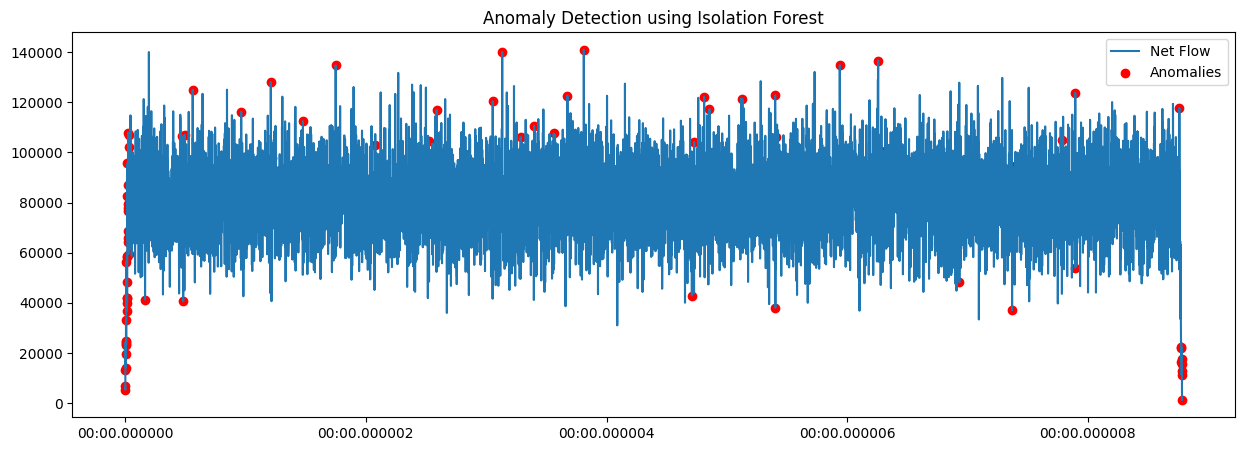

In [29]:
import matplotlib.pyplot as plt

plt.figure(figsize=(15,5))

plt.plot(df.loc[X.index].index,
         df.loc[X.index]['net_flow'],
         label='Net Flow')

anomalies = comparison[comparison['IsolationForest'] == 1]

plt.scatter(anomalies.index,
            df.loc[anomalies.index]['net_flow'],
            color='red',
            label='Anomalies')

plt.legend()
plt.title("Anomaly Detection using Isolation Forest")
plt.show()

In [30]:
df_anomalies = df.loc[comparison[comparison['IsolationForest'] == 1].index]

df_anomalies[['net_flow','lag_1','rolling_mean_24']].head()

,net_flow,lag_1,rolling_mean_24
date,,,
1970-01-01 00:00:00.000000000,6715.40,6715.40,43639.46125
1970-01-01 00:00:00.000000001,5328.48,6715.40,43639.46125
1970-01-01 00:00:00.000000002,13239.28,5328.48,43639.46125
1970-01-01 00:00:00.000000003,24236.07,13239.28,43639.46125
1970-01-01 00:00:00.000000004,19727.82,24236.07,43639.46125


# 🔍 Strong Anomaly Analysis (High Confidence)

In this step, we focus on **high-confidence anomalies** detected by all three models:
- Isolation Forest
- One-Class SVM
- Local Outlier Factor (LOF)

These anomalies are considered **most reliable** because all models agree on them.

---

## 🎯 Objective

To analyze and understand the behavior of strong anomalies and how they differ from normal patterns.

---

## 📌 Method

We extract only those data points where:

Isolation Forest = 1  
One-Class SVM = 1  
LOF = 1  

This gives us a subset of **high-confidence anomalies**.

---

## 📊 Key Features Analyzed

- **net_flow** → Current transaction flow (deposit - withdrawal)
- **lag_1** → Previous value of net flow
- **rolling_mean_24** → Average behavior over last 24 time steps

---

## 🧠 Observations

- Strong anomalies show **large deviation from rolling mean**
- Sudden spikes or drops in `net_flow`
- Inconsistent behavior compared to `lag_1`

These indicate **abnormal financial activity patterns**

---

## 💡 Interpretation

These anomalies may represent:

- Sudden large withdrawals
- Unexpected deposits
- Irregular transaction behavior
- Potential fraud or system irregularities

---

## ✅ Conclusion

By combining multiple models, we improve reliability and identify the most meaningful anomalies in the dataset.

In [31]:
strong_anomalies = df.loc[comparison[comparison['ALL_THREE'] == True].index]

strong_anomalies[['net_flow','lag_1','rolling_mean_24']].head()

,net_flow,lag_1,rolling_mean_24
date,,,
1970-01-01 00:00:00.000000029,59564.46,106765.15,60823.712500
1970-01-01 00:00:00.000000030,102009.40,59564.46,64044.513750
1970-01-01 00:00:00.000000493,107059.85,44999.70,81312.430833
1970-01-01 00:00:00.000002073,102883.05,45149.92,77016.114583
1970-01-01 00:00:00.000002523,104571.70,59746.77,78345.720833


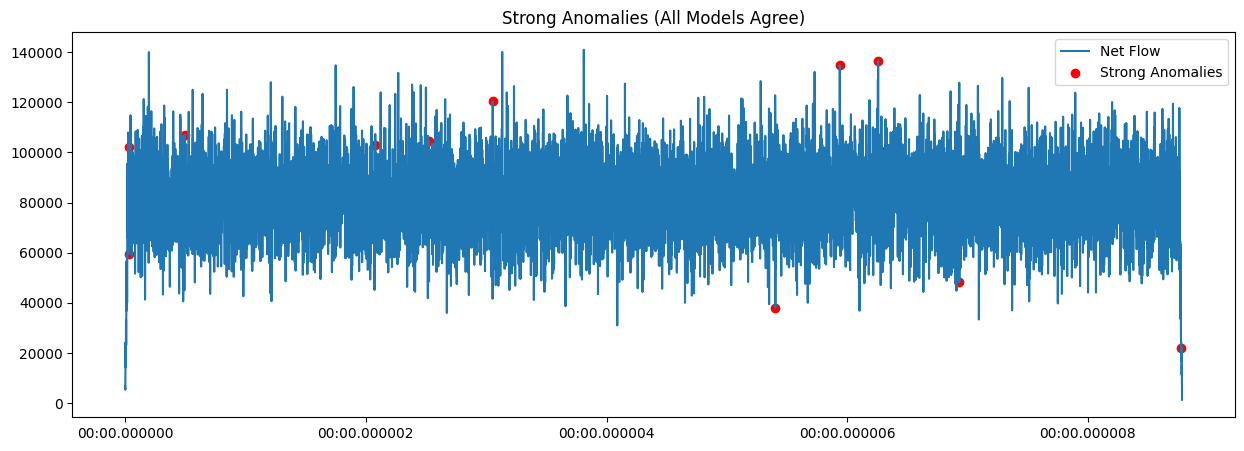

In [32]:
import matplotlib.pyplot as plt

plt.figure(figsize=(15,5))

plt.plot(df.loc[X.index].index,
         df.loc[X.index]['net_flow'],
         label='Net Flow')

strong = comparison[comparison['ALL_THREE'] == True]

plt.scatter(strong.index,
            df.loc[strong.index]['net_flow'],
            color='red',
            label='Strong Anomalies')

plt.legend()
plt.title("Strong Anomalies (All Models Agree)")
plt.show()

In [33]:
strong_anomalies.describe()

,amount,deposit_amount,withdrawal_amount,net_flow,hour,day_of_week,is_weekend,hour_sin,hour_cos,lag_1,lag_24,rolling_mean_24,rolling_std_24,net_flow_diff,pct_change,year,inflation_rate,interest_rate
count,13.000000,13.000000,13.000000,13.000000,13.000000,13.000000,13.000000,13.000000,1.300000e+01,13.000000,13.000000,13.000000,13.000000,13.000000,13.000000,13.000000,13.000000,13.000000
mean,202323.825385,145233.094615,57090.730769,88142.363846,10.692308,1.076923,0.153846,0.099182,-1.690751e-01,74087.233846,77091.563846,78962.191859,19139.660112,14055.130000,0.484543,2023.076923,5.595596,6.577205
std,47439.946508,40976.604570,11415.283494,36989.635223,5.864933,2.019139,0.375534,0.819305,6.086436e-01,35998.323241,35688.154750,9904.297331,4038.852764,60190.264841,0.864730,0.277350,0.193066,0.136587
min,68339.650000,45256.830000,23082.820000,22174.010000,3.000000,0.000000,0.000000,-1.000000,-9.659258e-01,27261.670000,14216.830000,60823.712500,11422.590309,-79621.160000,-0.665299,2023.000000,4.953036,6.375911
25%,191394.830000,126361.420000,55185.360000,59564.460000,6.000000,0.000000,0.000000,-0.707107,-7.071068e-01,45149.920000,54002.280000,77016.114583,17512.956655,-47200.690000,-0.442098,2023.000000,5.649143,6.473570
50%,214387.560000,157554.120000,61299.940000,102009.400000,10.000000,0.000000,0.000000,0.500000,-1.836970e-16,59746.770000,79985.890000,82210.754167,19002.638736,44824.930000,0.712588,2023.000000,5.649143,6.597370
75%,228498.860000,166535.280000,61963.580000,107059.850000,15.000000,1.000000,0.000000,0.707107,2.588190e-01,106765.150000,98174.340000,85222.725833,20817.034679,57733.130000,1.137492,2023.000000,5.649143,6.649270
max,259582.760000,198115.070000,67413.740000,136647.380000,20.000000,6.000000,1.000000,1.000000,7.071068e-01,136647.380000,129133.990000,90117.570000,25181.637790,78769.200000,1.891890,2024.000000,5.649143,6.823483
